# warm step-up sweep — variance, warm-up cost, and the per-run/overhead split

This notebook analyses the **`logs/warm_stepup/`** run on the server. Unlike the
parameter sweeps (`sharedBuffers`, `workMem`, …), here **nothing is swept** —
every run uses the same server configuration. What varies is the **batch size**
of a warm query and the fact that the whole thing is **repeated** with a server
restart in between.

**How the run is structured** (from `run_order.txt`): for every one of the
53 tpch query files a *group* is run as

* a fresh **server restart**, then
* **2 warm-ups** (`phase=warmup`, `batchnum=1`), then
* a **measured step-up**: one batch at `batchnum = 1, 2, 4, 8, 16`
  (`phase=measured`), where a batch of size *n* just runs the same warm query
  *n* times back-to-back.

Each query gets **3 such groups**, and the 159 groups (53 × 3) are executed in a
**random order** so slow drift or thermal effects don't line up with any one
query. One group = one `run_id`.

Two useful facts about the timing file:

* `avg_copy_elapsed_sec` is the **per-copy** time (`elapsed_sec / batchnum`);
* `elapsed_sec` is the **whole batch** time;
* `rapl_pkg_j` is the **whole batch** package energy, so per-copy energy is
  `rapl_pkg_j / batchnum`.

Every part of the analysis is reported for **both runtime and package energy
(RAPL `pkg`)**:

1. **Variance per `batchnum` per query** — how repeatable the per-copy time /
   energy is, and whether averaging over a bigger batch stabilises it.
2. **Warm-up statistics** — how the first (cold) run compares to the second
   warm-up and to the first genuinely warm measured run, in both time and energy.
3. **A line of best fit** of the whole-batch time / energy vs `batchnum` per
   query: the **slope** is the cost of one additional warm run, and the
   **y-intercept** is the fixed **overhead** paid once per batch.

Axes are kept **linear** wherever the data spans about one order of magnitude
(the batch axis uses evenly-spaced ticks rather than a log scale); no plot below
uses a log axis.


## 1. Fetch `logs/warm_stepup/` → local `ws_cache/`

Same fetch/cache idiom as the other notebooks (`sharedBuffers` → `sb_cache/`,
etc.): pull the files over SFTP with a few retries, mirror them into a **new**
local cache `ws_cache/`, and on any failure fall back to that cache. This sweep
lives in a single flat directory, so we just grab every `*.csv` plus
`run_order.txt`.


In [8]:
# %pip install paramiko pandas matplotlib
import io, re, time
from pathlib import Path
import numpy as np
import pandas as pd
import paramiko

SSH_HOST = "192.168.1.42"
SSH_USER = "user01"
SSH_PASS = "a"                       # demo credential
REMOTE_WS = "/home/user01/GreenSQL/logs/warm_stepup"
CACHE_DIR = Path("ws_cache")         # new cache, separate from the sweep caches
RETRIES = 5


def fetch_over_ssh():
    last = None
    for attempt in range(1, RETRIES + 1):
        try:
            cl = paramiko.SSHClient()
            cl.set_missing_host_key_policy(paramiko.AutoAddPolicy())
            cl.connect(SSH_HOST, username=SSH_USER, password=SSH_PASS,
                       timeout=45, banner_timeout=45, auth_timeout=45)
            try:
                with cl.open_sftp() as sftp:
                    blobs = {}
                    for fn in sftp.listdir(REMOTE_WS):
                        if fn.endswith(".csv") or fn == "run_order.txt":
                            blobs[fn] = sftp.open(f"{REMOTE_WS}/{fn}").read()
                    if not blobs:
                        raise RuntimeError(f"no files under {REMOTE_WS}")
                    return blobs
            finally:
                cl.close()
        except Exception as exc:
            last = exc
            print(f"  attempt {attempt}/{RETRIES} failed: {type(exc).__name__}")
            time.sleep(3)
    raise RuntimeError(f"SSH failed after {RETRIES} attempts: {last}")


def load():
    try:
        blobs = fetch_over_ssh()
        CACHE_DIR.mkdir(parents=True, exist_ok=True)
        for rel, b in blobs.items():
            (CACHE_DIR / rel).write_bytes(b)
        print(f"Fetched warm_stepup logs from {SSH_HOST}; "
              f"cache '{CACHE_DIR}/' updated.")
        return blobs, "server"
    except Exception as exc:
        if not CACHE_DIR.exists():
            raise RuntimeError(f"{exc}\nNo cache at '{CACHE_DIR}/'.") from exc
        blobs = {p.name: p.read_bytes()
                 for p in CACHE_DIR.iterdir() if p.is_file()}
        if not blobs:
            raise RuntimeError(f"{exc}\nCache '{CACHE_DIR}/' is empty.") from exc
        age_h = (time.time() - max((CACHE_DIR / r).stat().st_mtime
                                   for r in blobs)) / 3600
        print(f"\n!! {exc}")
        print(f"!! Falling back to cache '{CACHE_DIR}/' ({age_h:.1f} h old).\n")
        return blobs, "cache"


BLOBS, SOURCE = load()
print(f"source: {SOURCE};  files: {sorted(BLOBS)}")


Fetched warm_stepup logs from 192.168.1.42; cache 'ws_cache/' updated.
source: server;  files: ['query_catalog_tpch.csv', 'query_samples_tpch.csv', 'query_timing_tpch.csv', 'run_order.txt']


## 2. Build the per-run table

Read `query_timing_tpch.csv`, coerce the numeric columns, drop any failed rows,
and derive `qid` (`q05/base.sql`), `sql_file`, and `group` (`q05`) exactly like
the other notebooks. Each `run_id` is one group; within a query we number the
three groups **1–3 in the order they actually ran** (`repeat`), so we can line
up "the same batch size across the three restarts". Negative RAPL readings
(counter overflow) are set to `N/A`. Finally we split the rows into the
**warm-up** phase and the **measured** step-up phase, and add per-copy runtime
and per-copy package-energy columns.


In [9]:
def query_group(q):
    return re.sub(r"^queries/", "", str(q)).rsplit("/", 1)[0]


raw = pd.read_csv(io.BytesIO(BLOBS["query_timing_tpch.csv"]))
NUM = ["batch_index", "batchnum", "runs", "warmup", "elapsed_sec",
       "avg_copy_elapsed_sec", "server_sum_ms", "client_overhead_sec",
       "rapl_pkg_j", "rapl_core_j", "failed"]
for c in NUM:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")
raw = raw[raw["failed"].fillna(0) == 0].copy()
raw["timestamp_utc"] = pd.to_datetime(raw["timestamp_utc"], errors="coerce")

# RAPL counter overflow -> N/A (same guard as the sweep notebooks)
for c in ["rapl_pkg_j", "rapl_core_j"]:
    raw.loc[raw[c] < 0, c] = np.nan

raw["qid"] = raw["query"].astype(str).str.replace(
    r"^queries/tpch/tpch-queries/", "", regex=True)
raw["sql_file"] = raw["query"].astype(str).str.split("/").str[-1]
raw["group"] = raw["query"].map(query_group)

# number the 3 groups of each query 1..3 in the order they ran (by first stamp)
srt = raw.sort_values("timestamp_utc")
rep_map = {}
for qid, g in srt.groupby("qid"):
    for i, rid in enumerate(dict.fromkeys(g["run_id"]), 1):
        rep_map[(qid, rid)] = i
raw["repeat"] = [rep_map[(q, r)] for q, r in zip(raw["qid"], raw["run_id"])]

measured = raw[raw["phase"] == "measured"].copy()
warm = raw[raw["phase"] == "warmup"].copy()

# per-copy quantities (a batch of size n runs the query n times back-to-back)
measured["copy_time_s"] = measured["avg_copy_elapsed_sec"]
measured["copy_pkg_j"] = measured["rapl_pkg_j"] / measured["batchnum"]

BATCH = sorted(measured["batchnum"].dropna().unique().astype(int))
NREP = int(measured["repeat"].max())

reps = raw.groupby("qid")["repeat"].max()
print(f"{raw['qid'].nunique()} query files; {raw['run_id'].nunique()} groups "
      f"(run_ids); repeats per query: min={reps.min()}, max={reps.max()}")
print(f"batch sizes in the step-up: {BATCH}")
print(f"measured rows: {len(measured)}; warm-up rows: {len(warm)}")


53 query files; 159 groups (run_ids); repeats per query: min=3, max=3
batch sizes in the step-up: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16)]
measured rows: 795; warm-up rows: 318


## 3. Task 1 — variance of the per-copy time **and energy** at each `batchnum`

For a fixed query and a fixed `batchnum` we have **three** measured values (one
per restarted group). Their spread is the run-to-run reproducibility at that
batch size. We report the coefficient of variation `CV% = 100 · std / mean`
(unitless, so it's comparable across fast and slow queries) for **per-copy
runtime** and **per-copy package energy**.

The step-up exists precisely to test the expectation that **a larger batch
averages out per-invocation noise**, so the per-copy CV should generally *fall*
as `batchnum` grows. Each line below is the median CV across all queries at each
batch size (with the inter-quartile band and every query as a faint line). The
batch axis uses evenly-spaced ticks (`1, 2, 4, 8, 16`) and the y-axis is linear;
the y-limit is clipped to the bulk of the queries so the medians stay readable
(a few noisy queries — listed in the table — run off the top).


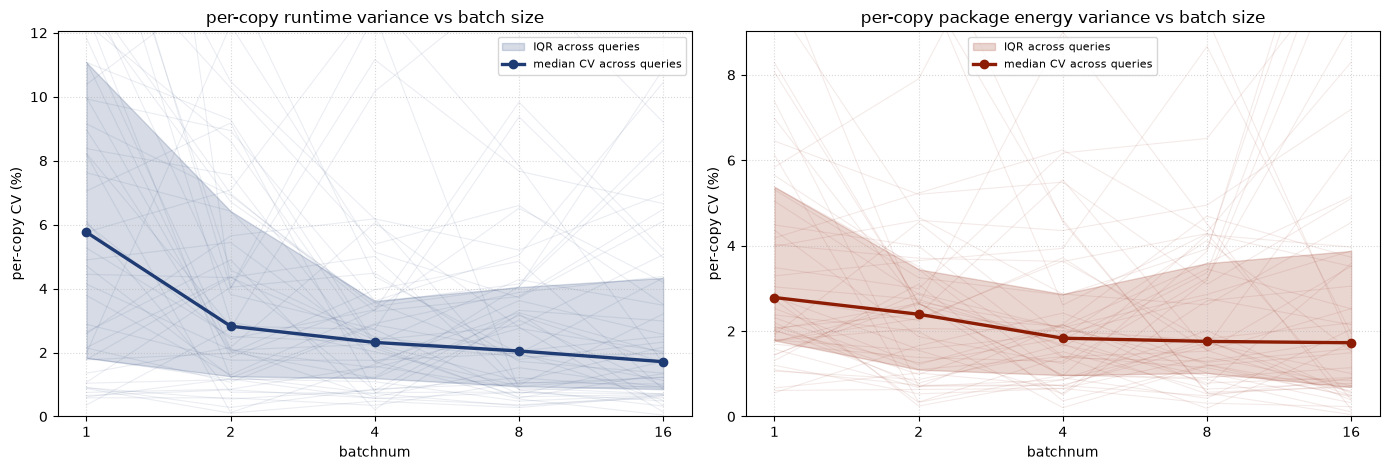

Median per-copy CV(%) by batch size (across 53 queries):
          runtime_cv%  energy_cv%
batchnum                         
1                5.76        2.79
2                2.82        2.39
4                2.32        1.83
8                2.05        1.76
16               1.71        1.73

Least reproducible queries at batchnum=1 (highest runtime CV%):
                     qid  mean_copy_s  std_copy_s  cv_pct
 q22/v1_materialized.sql       0.1213      0.0435 35.8137
 q04/v1_materialized.sql       0.1574      0.0300 19.0514
            q14/base.sql       0.3677      0.0695 18.9059
            q10/base.sql       0.3658      0.0672 18.3684
            q11/base.sql       0.1915      0.0336 17.5486
q11/v2_cte_threshold.sql       0.1840      0.0280 15.2128
 q11/v1_materialized.sql       0.1727      0.0234 13.5216
 q12/v1_materialized.sql       0.4647      0.0619 13.3209
       q12/v2_filter.sql       0.5366      0.0688 12.8162
            q06/base.sql       0.3527      0.0446 12.6540
 q

In [10]:
import matplotlib.pyplot as plt


def variance_table(col):
    v = measured.groupby(["qid", "batchnum"]).agg(
        n=(col, "size"), mean=(col, "mean"), std=(col, "std"),
    ).reset_index()
    v["cv_pct"] = 100 * v["std"] / v["mean"]
    return v


var_t = variance_table("copy_time_s")
var_e = variance_table("copy_pkg_j")
xpos = np.arange(len(BATCH))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, (v, title, color) in zip(
        axes,
        [(var_t, "per-copy runtime", "#1f3b73"),
         (var_e, "per-copy package energy", "#8c1d04")]):
    piv = v.pivot(index="qid", columns="batchnum", values="cv_pct").reindex(columns=BATCH)
    for _, row in piv.iterrows():
        ax.plot(xpos, row.values, color=color, alpha=0.09, lw=0.8)
    q1, q3 = piv.quantile(0.25), piv.quantile(0.75)
    ax.fill_between(xpos, q1.values, q3.values, color=color, alpha=0.18,
                    label="IQR across queries")
    ax.plot(xpos, piv.median().values, color=color, marker="o", lw=2.4,
            label="median CV across queries")
    ax.set_xticks(xpos); ax.set_xticklabels(BATCH)
    ax.set_xlabel("batchnum"); ax.set_ylabel("per-copy CV (%)")
    ax.set_ylim(0, float(np.nanpercentile(piv.values, 92)) * 1.15)
    ax.set_title(f"{title} variance vs batch size")
    ax.grid(linestyle=":", alpha=0.5); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print("Median per-copy CV(%) by batch size (across {} queries):".format(
    var_t["qid"].nunique()))
tab = pd.DataFrame({
    "runtime_cv%": var_t.groupby("batchnum")["cv_pct"].median(),
    "energy_cv%": var_e.groupby("batchnum")["cv_pct"].median(),
}).round(2)
print(tab.to_string())

print("\nLeast reproducible queries at batchnum=1 (highest runtime CV%):")
top = (var_t[var_t["batchnum"] == 1].sort_values("cv_pct", ascending=False)
       .head(12)[["qid", "mean", "std", "cv_pct"]]
       .rename(columns={"mean": "mean_copy_s", "std": "std_copy_s"}))
print(top.round(4).to_string(index=False))


## 4. Task 2 — warm-up statistics per query (runtime **and** energy)

Each group runs two warm-ups before the measured step-up. We line up, per group:

* **`warmup1`** — the very first execution after the restart (coldest: cold OS
  page cache / cold buffer cache);
* **`warmup2`** — the second warm-up;
* **`warm`** — the first *measured* single run (`batchnum=1`), the representative
  steady value.

Averaging the three groups per query, `cold penalty = warmup1 / warm` is how
much heavier the first cold run is than warm, and `warmup2 / warm` says whether
**one** warm-up already reaches steady state. Everything is a **ratio**, so the
bars are on a plain linear axis (no log needed). The left panel is runtime, the
right is package energy, for the same set of queries (ranked by runtime cold
penalty) so the two levers line up.


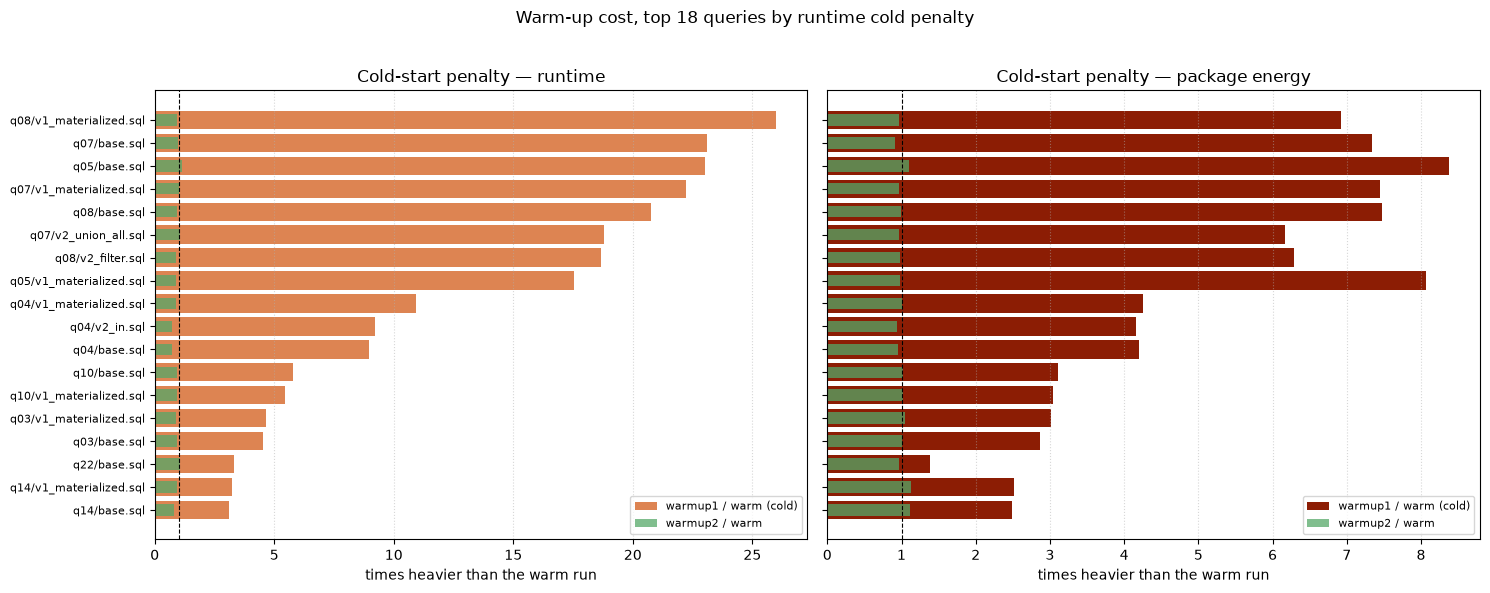

[runtime] cold penalty (warmup1/warm): median 2.61x, mean 5.66x, max 26.00x;  after 1 warm-up: median 0.93x, 50/53 queries within 5% of warm.
[energy] cold penalty (warmup1/warm): median 1.99x, mean 2.79x, max 8.38x;  after 1 warm-up: median 1.01x, 38/53 queries within 5% of warm.

Queries with the largest runtime cold penalty (with their energy penalty):
                    qid  warmup1_s  warm_s  cold_x_time  cold_x_energy
q08/v1_materialized.sql     12.678   0.490       26.004          6.917
           q07/base.sql      9.246   0.398       23.091          7.335
           q05/base.sql      7.397   0.321       23.003          8.376
q07/v1_materialized.sql      8.080   0.367       22.209          7.445
           q08/base.sql     10.470   0.504       20.782          7.471
   q07/v2_union_all.sql      6.816   0.367       18.779          6.169
      q08/v2_filter.sql      9.537   0.511       18.652          6.293
q05/v1_materialized.sql      6.524   0.372       17.527          8.061
q04

In [11]:
def warm_summary(metric):
    w1 = (warm[warm["batch_index"] == 1]
          .set_index(["qid", "repeat"])[metric].rename("w1"))
    w2 = (warm[warm["batch_index"] == 2]
          .set_index(["qid", "repeat"])[metric].rename("w2"))
    wr = (measured[measured["batchnum"] == 1]
          .set_index(["qid", "repeat"])[metric].rename("warm"))
    m = pd.concat([w1, w2, wr], axis=1).reset_index()
    m["cold"] = m["w1"] / m["warm"]
    m["after1"] = m["w2"] / m["warm"]
    return m.groupby("qid").agg(
        w1=("w1", "mean"), w2=("w2", "mean"), warm=("warm", "mean"),
        cold=("cold", "mean"), after1=("after1", "mean")).reset_index()


# runtime uses per-copy seconds; energy uses whole-run pkg joules (batchnum=1
# rows, so rapl_pkg_j already is the per-run energy)
wq_t = warm_summary("avg_copy_elapsed_sec")
wq_e = warm_summary("rapl_pkg_j")

order = wq_t.sort_values("cold", ascending=False).head(18)["qid"].tolist()
et = wq_e.set_index("qid")
y = np.arange(len(order))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, (src, title, c_cold) in zip(
        axes,
        [(wq_t.set_index("qid"), "runtime", "#dd8452"),
         (et, "package energy", "#8c1d04")]):
    cold = [src.loc[q, "cold"] for q in order]
    after1 = [src.loc[q, "after1"] for q in order]
    ax.barh(y, cold, color=c_cold, label="warmup1 / warm (cold)")
    ax.barh(y, after1, color="#55a868", alpha=0.75, height=0.5,
            label="warmup2 / warm")
    ax.axvline(1.0, color="k", lw=0.8, ls="--")
    ax.set_xlabel("times heavier than the warm run")
    ax.set_title(f"Cold-start penalty — {title}")
    ax.grid(axis="x", linestyle=":", alpha=0.5); ax.legend(fontsize=8)
axes[0].set_yticks(y); axes[0].set_yticklabels(order, fontsize=8)
axes[0].invert_yaxis()
fig.suptitle("Warm-up cost, top 18 queries by runtime cold penalty", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

for name, wq in [("runtime", wq_t), ("energy", wq_e)]:
    near = int((wq["after1"] <= 1.05).sum())
    print(f"[{name}] cold penalty (warmup1/warm): median {wq['cold'].median():.2f}x, "
          f"mean {wq['cold'].mean():.2f}x, max {wq['cold'].max():.2f}x;  "
          f"after 1 warm-up: median {wq['after1'].median():.2f}x, "
          f"{near}/{len(wq)} queries within 5% of warm.")

print("\nQueries with the largest runtime cold penalty (with their energy penalty):")
merged = wq_t[["qid", "w1", "warm", "cold"]].rename(
    columns={"w1": "warmup1_s", "warm": "warm_s", "cold": "cold_x_time"})
merged = merged.merge(
    wq_e[["qid", "cold"]].rename(columns={"cold": "cold_x_energy"}), on="qid")
print(merged.sort_values("cold_x_time", ascending=False).head(12)
      .round(3).to_string(index=False))


## 5. Task 3 — line of best fit: per-run cost (slope) vs fixed overhead (intercept)

For each query, plot the **whole-batch** quantity against `batchnum`, pooling all
three groups (up to 15 points), and fit an ordinary least-squares line

`y ≈ overhead + slope · batchnum`,   with `y = elapsed_sec` (runtime) or `y = rapl_pkg_j` (energy).

Because a batch just runs the same warm query `batchnum` times back-to-back, the
**slope** is the marginal **cost of one warm run** (seconds, or joules) and the
**y-intercept** (`batchnum → 0`) is the fixed **overhead** paid once per batch.
`R²` says how linear the step-up is. Both axes are linear — the whole point is
that the relationship *is* a straight line in `batchnum`.

The first figure is one representative query, runtime and energy side by side,
with the slope and intercept marked. Then a grid fits every query (runtime, then
energy), and finally the fixed overhead is summarised as a **fraction of one
run's cost** (linear) with the full fit table.


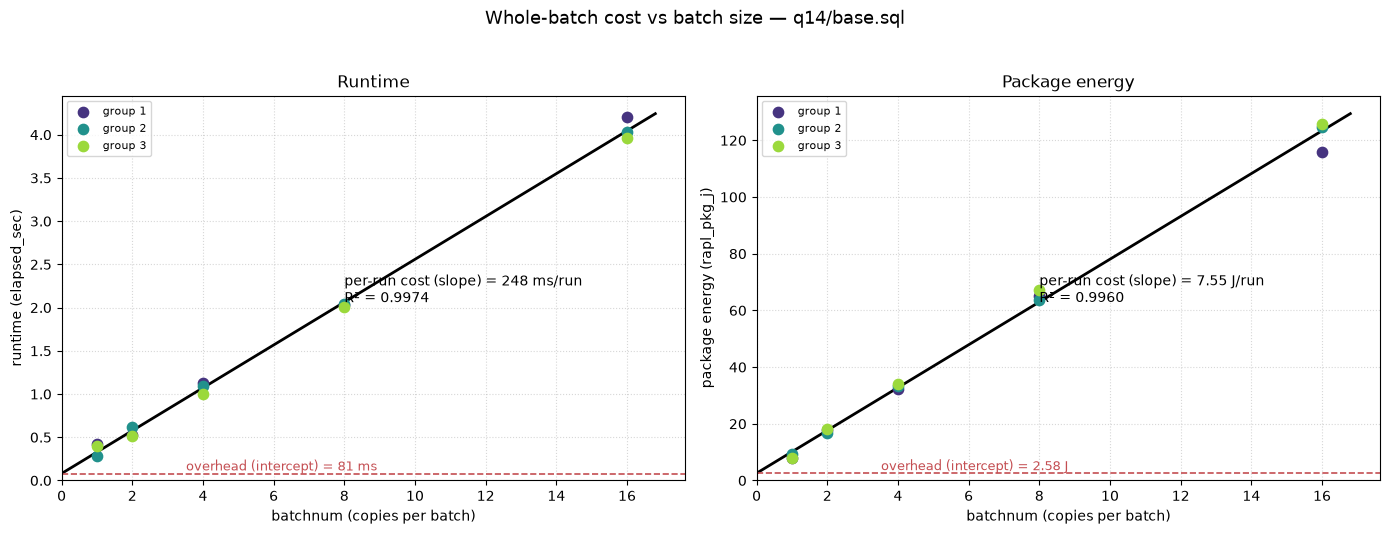

Headline query: q14/base.sql
  runtime: 247.8 ms/run, overhead 80.9 ms, R²=0.9974
  energy : 7.55 J/run, overhead 2.58 J, R²=0.9960


In [12]:
def fit_line(d, ycol):
    x = d["batchnum"].to_numpy(float)
    y = d[ycol].to_numpy(float)
    ok = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[ok], y[ok]
    if len(x) < 2 or np.ptp(x) == 0:
        return None
    slope, intercept = np.polyfit(x, y, 1)
    yhat = intercept + slope * x
    ss_res = float(((y - yhat) ** 2).sum())
    ss_tot = float(((y - y.mean()) ** 2).sum())
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return slope, intercept, r2, len(x)


def fit_all(ycol):
    rows = []
    for qid, d in measured.groupby("qid"):
        res = fit_line(d, ycol)
        if res is None:
            continue
        rows.append(dict(qid=qid, slope=res[0], overhead=res[1],
                         r2=res[2], n=res[3]))
    return pd.DataFrame(rows)


fit_t = fit_all("elapsed_sec")     # runtime: slope s/run, overhead s
fit_e = fit_all("rapl_pkg_j")      # energy:  slope J/run, overhead J

# a *typical* clearly-linear query (median runtime per-run cost, positive
# overhead) so the slope and a visible positive intercept both read off the plot
cand = fit_t[(fit_t["r2"] > 0.99) & (fit_t["overhead"] > 0)].copy()
if len(cand):
    med = cand["slope"].median()
    head_qid = cand.loc[(cand["slope"] - med).abs().idxmin(), "qid"]
else:
    head_qid = fit_t.iloc[len(fit_t) // 2]["qid"]

d = measured[measured["qid"] == head_qid]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, NREP))
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for ax, (fitdf, ycol, unit, scale, nice) in zip(
        axes,
        [(fit_t, "elapsed_sec", "ms", 1000, "runtime (elapsed_sec)"),
         (fit_e, "rapl_pkg_j", "J", 1, "package energy (rapl_pkg_j)")]):
    r = fitdf[fitdf["qid"] == head_qid].iloc[0]
    slope, intercept, r2 = r["slope"], r["overhead"], r["r2"]
    for rp, g in d.groupby("repeat"):
        ax.scatter(g["batchnum"], g[ycol], s=55, color=colors[int(rp) - 1],
                   label=f"group {int(rp)}", zorder=3)
    xs = np.linspace(0, max(BATCH) * 1.05, 100)
    ax.plot(xs, intercept + slope * xs, "k-", lw=2)
    ax.axhline(intercept, color="#c44e52", ls="--", lw=1.2)
    u = f"{intercept * scale:.0f} {unit}" if scale != 1 else f"{intercept:.2f} {unit}"
    su = f"{slope * scale:.0f} {unit}/run" if scale != 1 else f"{slope:.2f} {unit}/run"
    ax.annotate(f"overhead (intercept) = {u}", xy=(0, intercept),
                xytext=(max(BATCH) * 0.22, intercept), color="#c44e52",
                fontsize=9, va="bottom")
    ax.annotate(f"per-run cost (slope) = {su}\nR² = {r2:.4f}",
                xy=(max(BATCH) * 0.5, intercept + slope * max(BATCH) * 0.5),
                fontsize=10)
    ax.set_xlim(left=0); ax.set_ylim(bottom=0)
    ax.set_xlabel("batchnum (copies per batch)")
    ax.set_ylabel(nice)
    ax.set_title(nice.split(" (")[0].capitalize())
    ax.grid(linestyle=":", alpha=0.5); ax.legend(fontsize=8)
fig.suptitle(f"Whole-batch cost vs batch size — {head_qid}", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

rt = fit_t[fit_t["qid"] == head_qid].iloc[0]
en = fit_e[fit_e["qid"] == head_qid].iloc[0]
print(f"Headline query: {head_qid}")
print(f"  runtime: {rt['slope']*1000:.1f} ms/run, overhead {rt['overhead']*1000:.1f} ms, R²={rt['r2']:.4f}")
print(f"  energy : {en['slope']:.2f} J/run, overhead {en['overhead']:.2f} J, R²={en['r2']:.4f}")


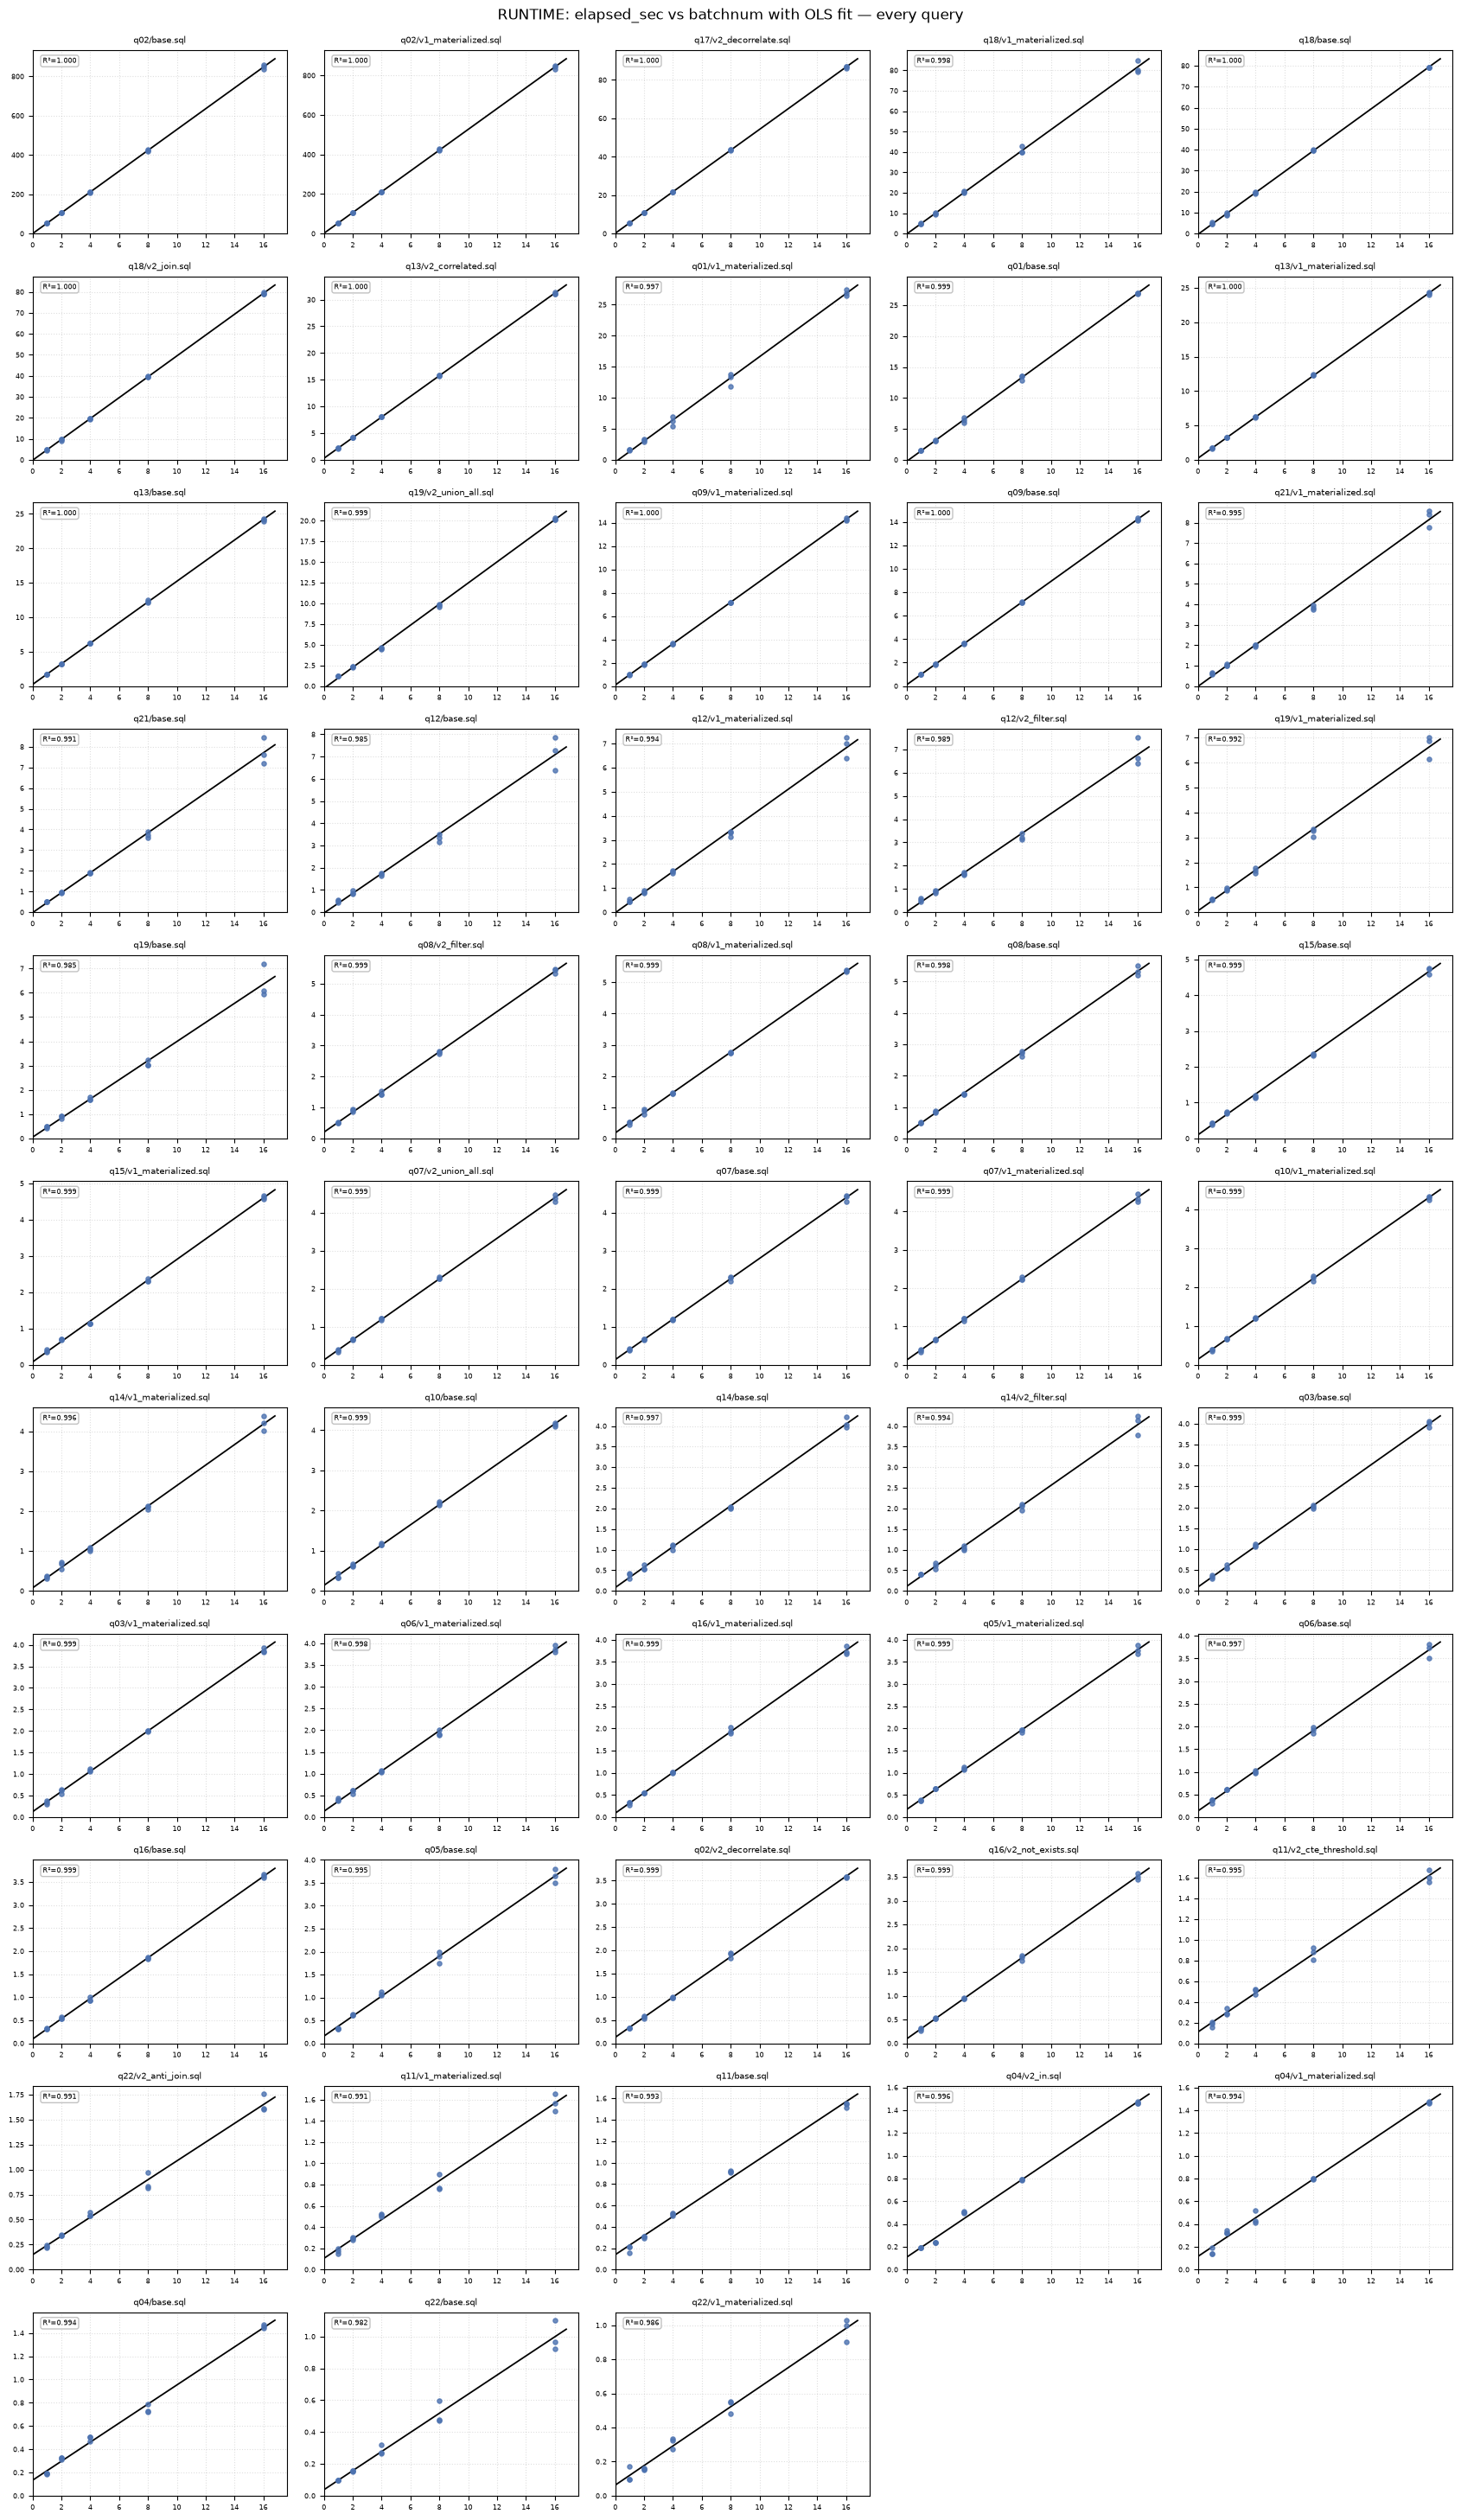

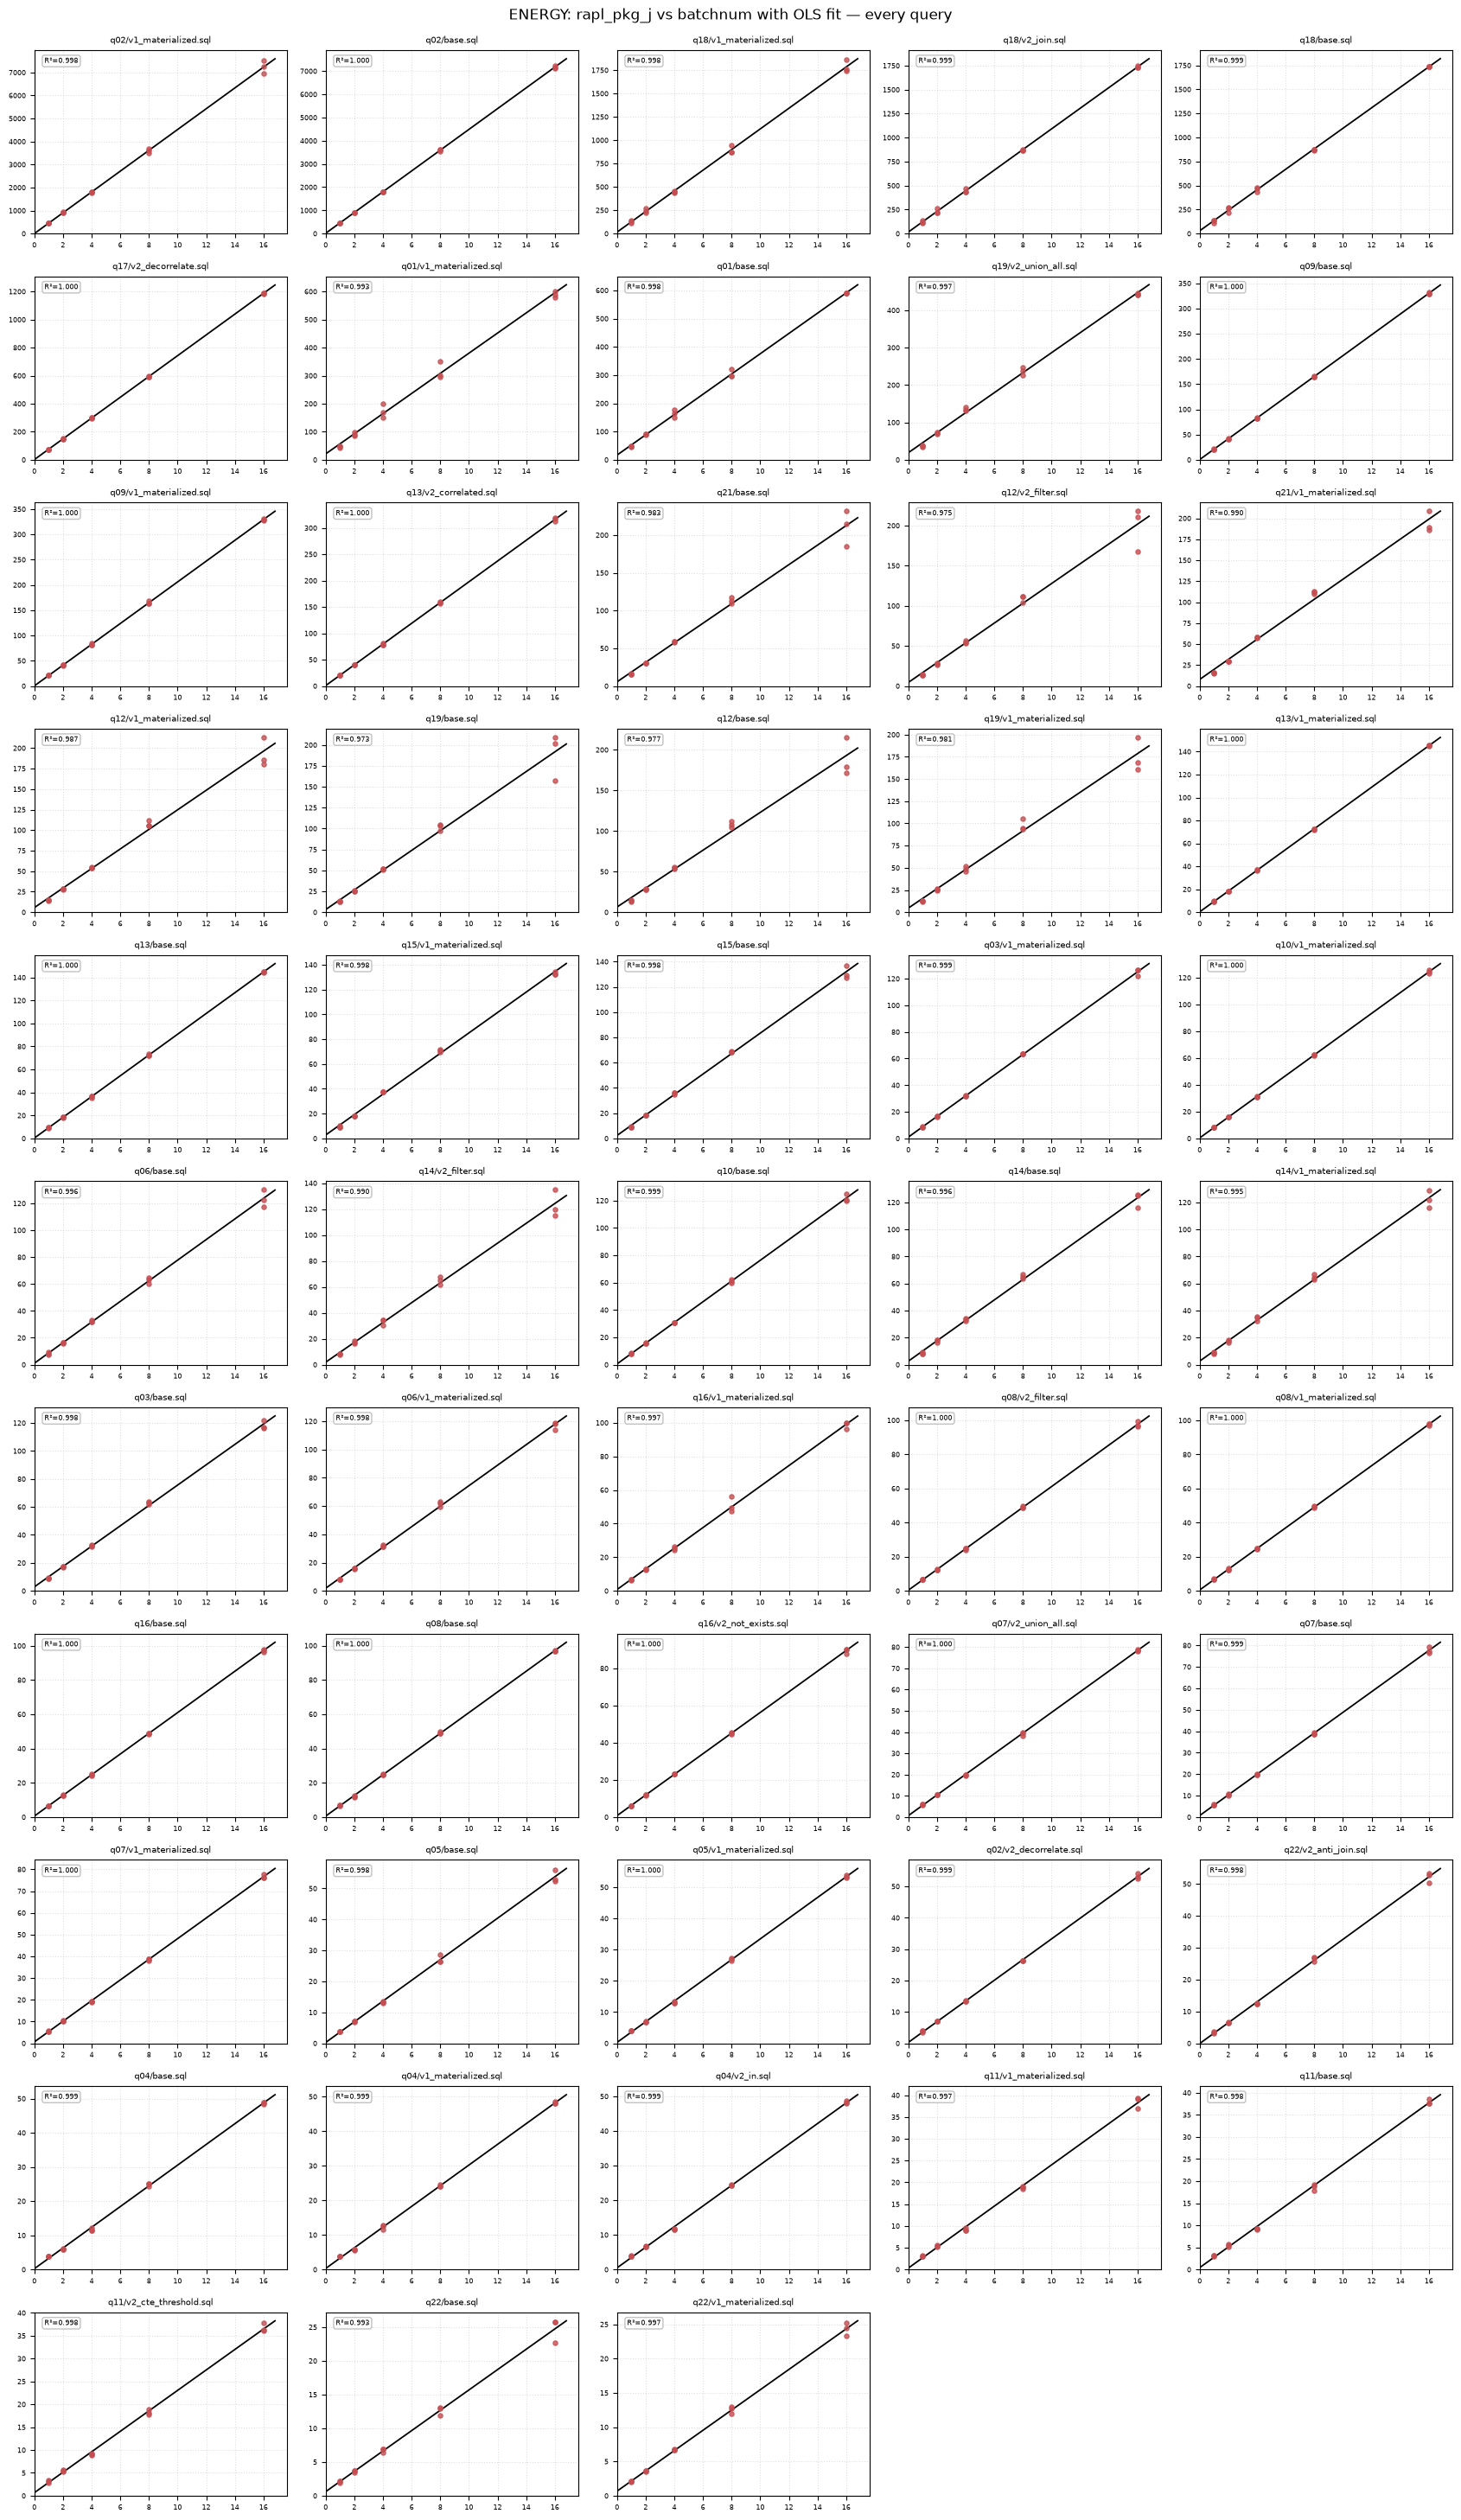

In [13]:
def draw_grid(fitdf, ycol, dot, title):
    order = fitdf.sort_values("slope", ascending=False)["qid"].tolist()
    ncols = 5
    nrows = int(np.ceil(len(order) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.4, nrows * 2.7))
    axes = np.atleast_1d(axes).ravel()
    xs = np.linspace(0, max(BATCH) * 1.05, 50)
    for ax, qid in zip(axes, order):
        d = measured[measured["qid"] == qid]
        r = fitdf[fitdf["qid"] == qid].iloc[0]
        ax.scatter(d["batchnum"], d[ycol], s=14, color=dot, alpha=0.8, zorder=3)
        ax.plot(xs, r["overhead"] + r["slope"] * xs, "k-", lw=1.3)
        ax.set_title(qid, fontsize=7)
        ax.set_xlim(left=0); ax.set_ylim(bottom=0)
        ax.tick_params(labelsize=6)
        ax.text(0.04, 0.96, f"R²={r['r2']:.3f}", transform=ax.transAxes,
                fontsize=6, va="top",
                bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.8))
        ax.grid(linestyle=":", alpha=0.4)
    for ax in axes[len(order):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.985]); plt.show()


draw_grid(fit_t, "elapsed_sec", "#4c72b0",
          "RUNTIME: elapsed_sec vs batchnum with OLS fit — every query")
draw_grid(fit_e, "rapl_pkg_j", "#c44e52",
          "ENERGY: rapl_pkg_j vs batchnum with OLS fit — every query")


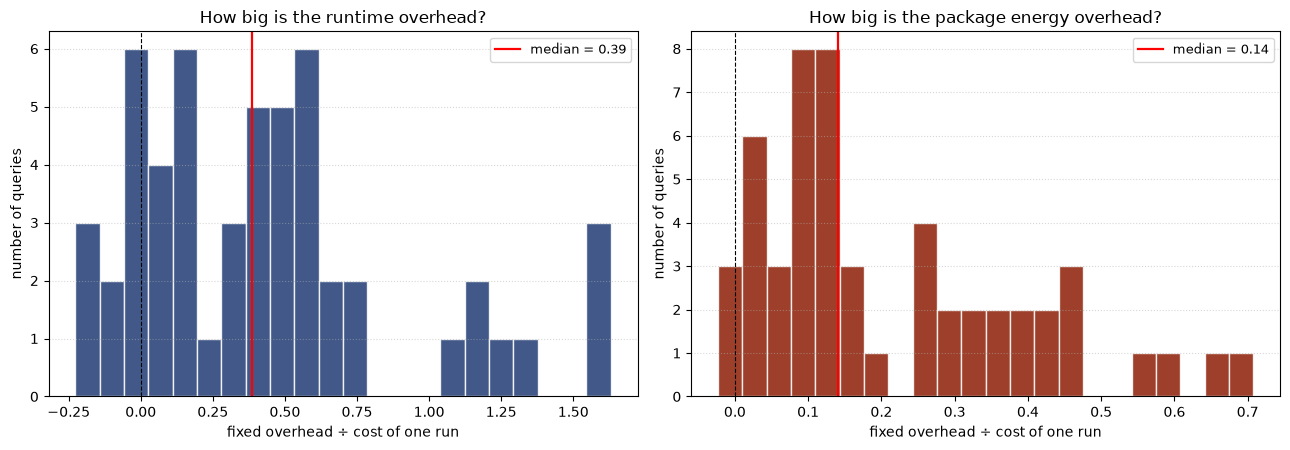

runtime: 11 queries have a small negative intercept; median R² = 0.9986
energy : 2 queries have a small negative intercept; median R² = 0.9984
per-run cost: runtime median 266.5 ms; energy median 7.65 J
overhead: runtime median 105.3 ms; energy median 0.73 J

Full fit table (sorted by runtime per-run cost):
                     qid  run_cost_ms  run_ovh_ms  run_r2  en_cost_j  en_ovh_j  en_r2
            q02/base.sql      52944.8      -114.9  0.9998     447.61     12.21 0.9999
 q02/v1_materialized.sql      52550.4      1484.3  0.9998     452.04     -0.48 0.9980
  q17/v2_decorrelate.sql       5408.3       161.5  0.9999      74.13      1.19 1.0000
 q18/v1_materialized.sql       5111.1      -233.2  0.9980     110.57     15.23 0.9975
            q18/base.sql       4978.4      -370.0  0.9998     106.60     28.91 0.9993
         q18/v2_join.sql       4967.9      -217.8  0.9998     107.53     15.86 0.9993
   q13/v2_correlated.sql       1933.0       281.6  0.9999      19.70      0.73 0.9999
 q0

In [14]:
# ---- summary: fixed overhead as a fraction of one run's cost (linear) ----
fit_t["ovh_frac"] = fit_t["overhead"] / fit_t["slope"]
fit_e["ovh_frac"] = fit_e["overhead"] / fit_e["slope"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, (f, title, color) in zip(
        axes,
        [(fit_t, "runtime", "#1f3b73"), (fit_e, "package energy", "#8c1d04")]):
    vals = f["ovh_frac"].clip(-0.5, 2.5)
    ax.hist(vals, bins=22, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.axvline(f["ovh_frac"].median(), color="red", lw=1.6,
               label=f"median = {f['ovh_frac'].median():.2f}")
    ax.set_xlabel("fixed overhead ÷ cost of one run")
    ax.set_ylabel("number of queries")
    ax.set_title(f"How big is the {title} overhead?")
    ax.grid(axis="y", linestyle=":", alpha=0.5); ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

print(f"runtime: {(fit_t['overhead'] < 0).sum()} queries have a small negative "
      f"intercept; median R² = {fit_t['r2'].median():.4f}")
print(f"energy : {(fit_e['overhead'] < 0).sum()} queries have a small negative "
      f"intercept; median R² = {fit_e['r2'].median():.4f}")
print(f"per-run cost: runtime median {fit_t['slope'].median()*1000:.1f} ms; "
      f"energy median {fit_e['slope'].median():.2f} J")
print(f"overhead: runtime median {fit_t['overhead'].median()*1000:.1f} ms; "
      f"energy median {fit_e['overhead'].median():.2f} J")

comb = fit_t[["qid", "slope", "overhead", "r2"]].rename(
    columns={"slope": "run_cost_s", "overhead": "run_ovh_s", "r2": "run_r2"})
comb = comb.merge(fit_e[["qid", "slope", "overhead", "r2"]].rename(
    columns={"slope": "en_cost_j", "overhead": "en_ovh_j", "r2": "en_r2"}), on="qid")
comb["run_cost_ms"] = (comb["run_cost_s"] * 1000).round(1)
comb["run_ovh_ms"] = (comb["run_ovh_s"] * 1000).round(1)
comb["en_cost_j"] = comb["en_cost_j"].round(2)
comb["en_ovh_j"] = comb["en_ovh_j"].round(2)
comb["run_r2"] = comb["run_r2"].round(4)
comb["en_r2"] = comb["en_r2"].round(4)
print("\nFull fit table (sorted by runtime per-run cost):")
print(comb.sort_values("run_cost_ms", ascending=False)[
    ["qid", "run_cost_ms", "run_ovh_ms", "run_r2",
     "en_cost_j", "en_ovh_j", "en_r2"]].to_string(index=False))


## 6. Residuals of the linear fit vs `batchnum`

A straight line is only the right model if its **residuals** (`observed −
fitted`) are unstructured. Here we take every measured point, subtract the
per-query fit from §5, and express the residual as a **percentage of the fitted
value** so the 53 queries — which span from ~60 ms to ~53 s per run — are all on
the same axis. We do this for runtime and package energy.

Reading the plot: points scattered symmetrically around **0** at every batch
size means the line fits well; a consistent **curve** (e.g. all-positive at the
ends and negative in the middle, or vice-versa) would signal that cost is *not*
quite linear in `batchnum`; and a **funnel** that narrows as `batchnum` grows is
the same noise-averaging effect seen in the variance sections. The box shows the
inter-quartile range per batch size (whiskers 5–95%), with the raw points
jittered behind it.


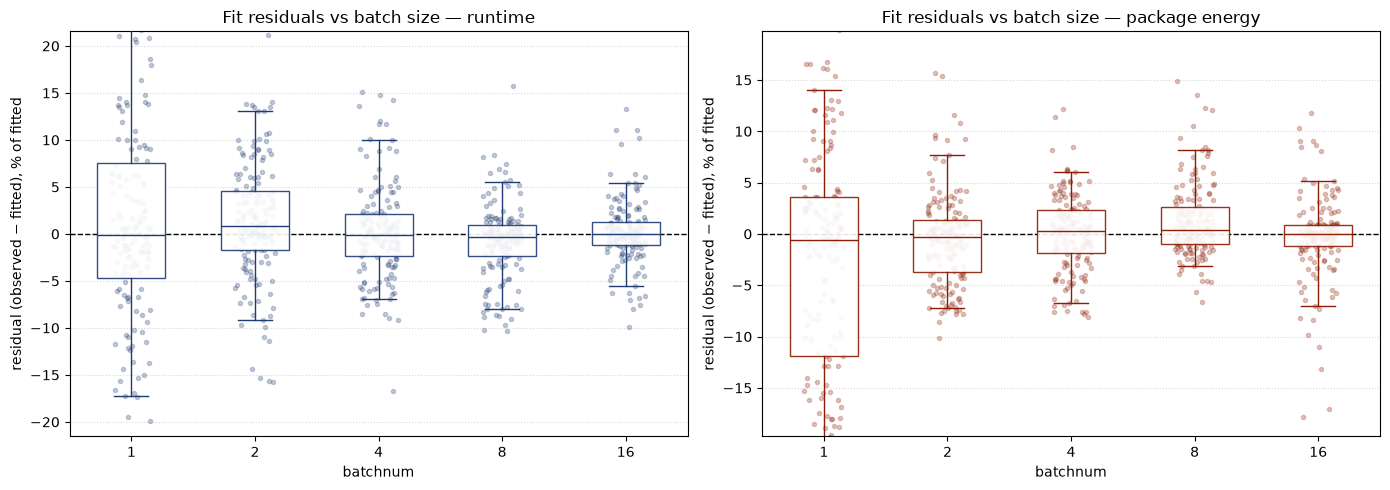

Median residual (% of fitted) by batch size — a systematic sign here would mean the fit is slightly non-linear:
          runtime_%  energy_%
batchnum                     
1             -0.17     -0.63
2              0.85     -0.33
4             -0.12      0.25
8             -0.29      0.36
16            -0.03     -0.05

Residual spread (std of % residual) by batch size:
          runtime_%  energy_%
batchnum                     
1             12.83     11.00
2              6.41      4.52
4              4.96      4.10
8              3.94      3.61
16             3.37      4.02


In [15]:
rng = np.random.default_rng(0)


def residual_frame(fitdf, ycol):
    f = fitdf.set_index("qid")
    d = measured.dropna(subset=[ycol]).copy()
    d = d[d["qid"].isin(f.index)]
    yhat = (f.loc[d["qid"], "overhead"].to_numpy()
            + f.loc[d["qid"], "slope"].to_numpy() * d["batchnum"].to_numpy())
    d["yhat"] = yhat
    d["rel_resid_pct"] = 100 * (d[ycol] - d["yhat"]) / d["yhat"]
    return d


res_t = residual_frame(fit_t, "elapsed_sec")
res_e = residual_frame(fit_e, "rapl_pkg_j")
pos = {b: i for i, b in enumerate(BATCH)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (res, title, color) in zip(
        axes, [(res_t, "runtime", "#1f3b73"),
                (res_e, "package energy", "#8c1d04")]):
    xi = res["batchnum"].map(pos).to_numpy(float)
    ax.scatter(xi + rng.uniform(-0.16, 0.16, len(xi)), res["rel_resid_pct"],
               s=9, color=color, alpha=0.25, zorder=2)
    box = [res.loc[res["batchnum"] == b, "rel_resid_pct"].values for b in BATCH]
    bp = ax.boxplot(box, positions=range(len(BATCH)), widths=0.55,
                    whis=(5, 95), showfliers=False, patch_artist=True, zorder=3)
    for patch in bp["boxes"]:
        patch.set(facecolor="white", edgecolor=color, alpha=0.9)
    for el in ("whiskers", "caps", "medians"):
        for ln in bp[el]:
            ln.set_color(color)
    ax.axhline(0, color="k", lw=1.0, ls="--")
    ax.set_xticks(range(len(BATCH))); ax.set_xticklabels(BATCH)
    lim = float(np.nanpercentile(np.abs(res["rel_resid_pct"]), 97))
    ax.set_ylim(-lim * 1.1, lim * 1.1)
    ax.set_xlabel("batchnum")
    ax.set_ylabel("residual (observed − fitted), % of fitted")
    ax.set_title(f"Fit residuals vs batch size — {title}")
    ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

print("Median residual (% of fitted) by batch size — a systematic sign here "
      "would mean the fit is slightly non-linear:")
tab = pd.DataFrame({
    "runtime_%": res_t.groupby("batchnum")["rel_resid_pct"].median(),
    "energy_%": res_e.groupby("batchnum")["rel_resid_pct"].median(),
}).round(2)
print(tab.to_string())
print("\nResidual spread (std of % residual) by batch size:")
tab2 = pd.DataFrame({
    "runtime_%": res_t.groupby("batchnum")["rel_resid_pct"].std(),
    "energy_%": res_e.groupby("batchnum")["rel_resid_pct"].std(),
}).round(2)
print(tab2.to_string())


## 7. Time (and energy) vs variance — does query size drive the noise?

Each point is one `(query, batchnum)`: its **mean per-copy** cost on the x-axis
against its **CV%** (the run-to-run spread from §3) on the y-axis, coloured by
`batchnum`. This asks whether the fast, tiny queries are the noisy ones (fixed
timer / scheduling jitter being a big fraction of a small number) while the long
queries are relatively steady. The x-axis is clipped to the bulk of the queries
so the dense region is readable — a few very slow queries (e.g. `q02`, ~53 s)
sit far to the right with low CV and are off-scale by design.


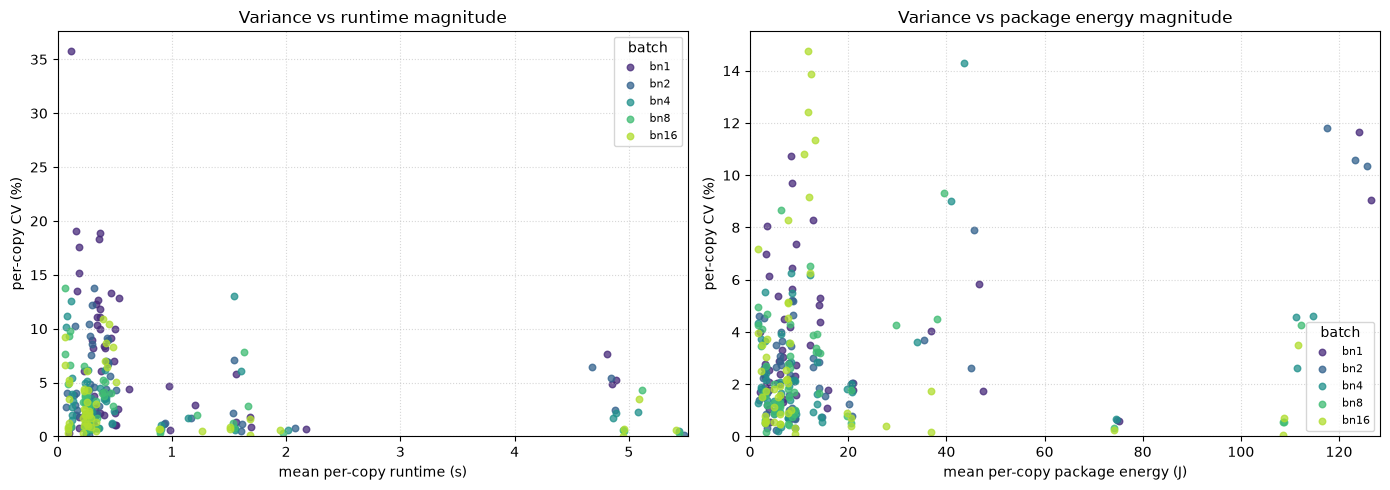

At batchnum=1, fastest third of queries: median CV 9.7%; slowest third: median CV 2.2%.
Correlation (mean per-copy time vs CV%), all points: -0.17


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colB = plt.cm.viridis(np.linspace(0.12, 0.88, len(BATCH)))
for ax, (v, title, unit) in zip(
        axes, [(var_t, "runtime", "s"), (var_e, "package energy", "J")]):
    for j, b in enumerate(BATCH):
        s = v[v["batchnum"] == b]
        ax.scatter(s["mean"], s["cv_pct"], s=22, color=colB[j], alpha=0.75,
                   label=f"bn{b}")
    ax.set_xlim(0, float(np.nanpercentile(v["mean"], 96)))
    ax.set_ylim(bottom=0)
    ax.set_xlabel(f"mean per-copy {title} ({unit})")
    ax.set_ylabel("per-copy CV (%)")
    ax.set_title(f"Variance vs {title} magnitude")
    ax.grid(linestyle=":", alpha=0.5); ax.legend(fontsize=8, title="batch")
fig.tight_layout(); plt.show()

# fast vs slow tertiles at batchnum=1 (runtime)
b1 = var_t[var_t["batchnum"] == 1].dropna(subset=["mean", "cv_pct"])
q33, q67 = b1["mean"].quantile([1/3, 2/3])
fast = b1[b1["mean"] <= q33]["cv_pct"].median()
slow = b1[b1["mean"] >= q67]["cv_pct"].median()
print(f"At batchnum=1, fastest third of queries: median CV {fast:.1f}%; "
      f"slowest third: median CV {slow:.1f}%.")
print("Correlation (mean per-copy time vs CV%), all points: "
      f"{np.corrcoef(var_t['mean'].fillna(0), var_t['cv_pct'].fillna(0))[0,1]:.2f}")


## 8. Variance vs `batchnum` — absolute spread

§3 showed the *relative* spread (CV%). This shows the **absolute** per-copy
standard deviation and how it collapses as the batch grows: the median per-copy
std across queries with the inter-quartile band and every query as a faint line.
Evenly-spaced batch ticks, linear y (clipped to the bulk so the median stays
readable). Units are seconds (runtime) and joules (energy) — the actual size of
the jitter you'd see on a single warm copy at each batch size.


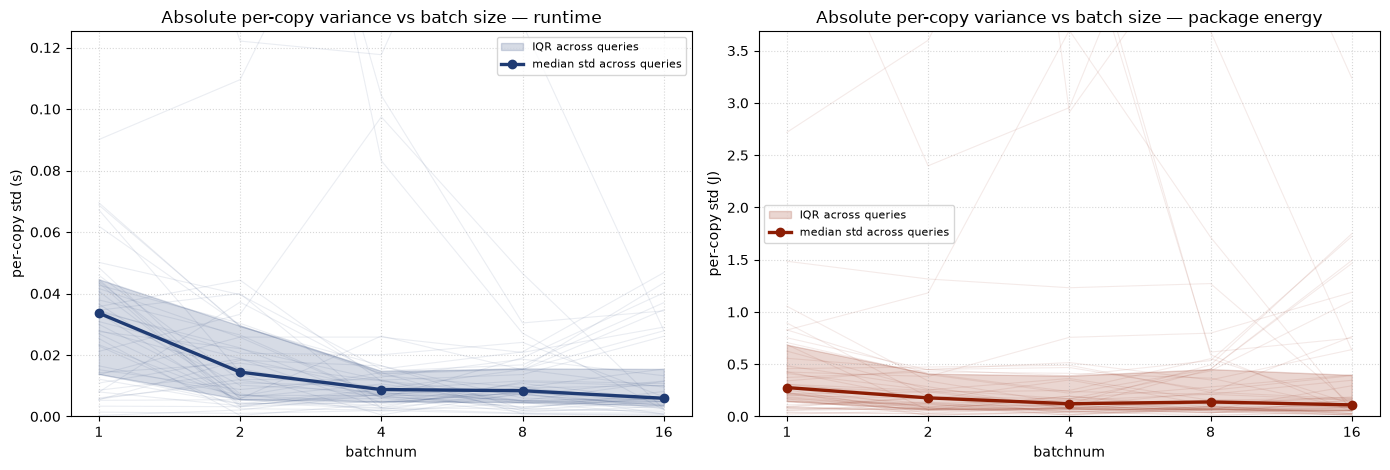

Median absolute per-copy std by batch size:
          runtime_std_s  energy_std_j
batchnum                             
1                0.0336        0.2767
2                0.0144        0.1782
4                0.0088        0.1223
8                0.0084        0.1391
16               0.0059        0.1112


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, (v, title, color, unit) in zip(
        axes, [(var_t, "runtime", "#1f3b73", "s"),
                (var_e, "package energy", "#8c1d04", "J")]):
    piv = v.pivot(index="qid", columns="batchnum", values="std").reindex(columns=BATCH)
    for _, row in piv.iterrows():
        ax.plot(xpos, row.values, color=color, alpha=0.09, lw=0.8)
    ax.fill_between(xpos, piv.quantile(0.25).values, piv.quantile(0.75).values,
                    color=color, alpha=0.18, label="IQR across queries")
    ax.plot(xpos, piv.median().values, color=color, marker="o", lw=2.4,
            label="median std across queries")
    ax.set_xticks(xpos); ax.set_xticklabels(BATCH)
    ax.set_ylim(0, float(np.nanpercentile(piv.values, 92)) * 1.15)
    ax.set_xlabel("batchnum")
    ax.set_ylabel(f"per-copy std ({unit})")
    ax.set_title(f"Absolute per-copy variance vs batch size — {title}")
    ax.grid(linestyle=":", alpha=0.5); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print("Median absolute per-copy std by batch size:")
tab = pd.DataFrame({
    "runtime_std_s": var_t.groupby("batchnum")["std"].median(),
    "energy_std_j": var_e.groupby("batchnum")["std"].median(),
}).round(4)
print(tab.to_string())
